In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.geoaxes import GeoAxes
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

In [4]:
from xmip.preprocessing import combined_preprocessing
import regionmask
from xmip.regionmask import merged_mask
import warnings
import matplotlib.pyplot as plt
import numpy as np
import glob
import xarray as xr
import xbudget
import regionate
import xwmt
import xwmb
import xgcm
import matplotlib.colors as mcolors
import cmocean
import cartopy.crs as ccrs
from scipy.interpolate import PchipInterpolator
# import CM4Xutils #needed to run pip install nc-time-axis
# from regionate import MaskRegions, GriddedRegion
import sys
sys.path.insert(0, '/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/src')
from src import *
import matplotlib as mpl
mpl.rcParams['figure.dpi'] = 150

### Request HPC Resources

In [5]:
from dask_jobqueue import SLURMCluster  # setup dask cluster 
from dask.distributed import Client

log_directory="/vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs"

cluster = SLURMCluster(
    cores=36,
    processes=1,
    memory='190GB',
    walltime='03:00:00',
    queue='compute',
    interface='ib0', 
log_directory = log_directory)
print(cluster.job_script())
cluster.scale(jobs=16)

client = Client(cluster)
client

#!/usr/bin/env bash

#SBATCH -J dask-worker
#SBATCH -e /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.err
#SBATCH -o /vortexfs1/home/anthony.meza/scratch/CM4X/CM4XTransientTracers/WaterMassBudgets/logs/dask-worker-%J.out
#SBATCH -p compute
#SBATCH -n 1
#SBATCH --cpus-per-task=36
#SBATCH --mem=177G
#SBATCH -t 03:00:00

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/bin/python -m distributed.cli.dask_worker tcp://172.16.3.74:36304 --name dummy-name --nthreads 36 --memory-limit 176.95GiB --nanny --death-timeout 60 --interface ib0



Connection method: Cluster object,Cluster type: dask_jobqueue.SLURMCluster
Dashboard: /proxy/8787/status,
Dashboard: /proxy/8787/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://172.16.3.74:36304,Workers: 0
Dashboard: /proxy/8787/status,Total threads: 0
Started: Just now,Total memory: 0 B


In [6]:
native_path = "/vortexfs1/home/anthony.meza/scratch/CM4XAbyssalSWMT/data/model/transient_tracers_z"
files = ["CM4Xp125_piControl_transient_tracers_z.zarr", "CM4Xp125_historical_transient_tracers_z.zarr", "CM4Xp125_ssp585_transient_tracers_z.zarr"]
full_depth_files = [native_path + "/" + a for a in files]

files = ["CM4Xp125_piControl_transient_tracers_surface.zarr", 
         "CM4Xp125_historical_transient_tracers_surface.zarr", 
         "CM4Xp125_ssp585_transient_tracers_surface.zarr"]
surface_files = [native_path + "/" + a for a in files]

In [7]:
def preprocess(ds):
    if ("year_ctrl" in ds.coords) or ("time_ctrl" in ds.coords):
        # if "time_ctrl" in ds.coords:
        #     ds = ds.reset_coords("year_ctrl", drop=True)
        # else:
        #     ds = ds.reset_coords("time_ctrl", drop=True)
        ds = ds.expand_dims(expt=["control"])
        ds.coords["year"] = ds.coords["year"]
        ds = ds.drop_vars(["year_ctrl"])
    else: 
        ds = ds.expand_dims(expt=["forced"])        
    return ds.isel(yh = slice(0, 120)).sel(year = slice(None, 2099))
ds_ctrl= xr.open_mfdataset(full_depth_files[0], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")
ds_forced = xr.open_mfdataset(full_depth_files[1:], combine="nested", concat_dim=["year"], parallel=True, preprocess=preprocess, engine = "zarr")

ds= xr.concat([ds_ctrl, ds_forced], dim = "expt")

In [8]:
rename_geocoords = lambda ds: ds.rename({"lat":"old_lat", "lon":"old_lon"}).rename({"geolat":"lat", "geolon":"lon"})

def setup_regridder(ds, ds_locs):
    ds_tmp_coords = ds[["geolat", "geolon"]]
    ds_tmp_coords = rename_geocoords(ds_tmp_coords).compute()
    
    regridder = xe.Regridder(ds_tmp_coords, ds_locs, "bilinear", locstream_out=True)

    return regridder

def apply_regridder(regridder, ds):
    ds_sampled = regridder(ds.reset_coords(["geolon", "geolat", "wet"], drop = False))
    ds_sampled = ds_sampled.drop_vars(['geolat_c', 'geolon_c', "xq", "yq"])
    ds_sampled = ds_sampled.set_coords(["wet", "geolon", "geolat"])
    for v in ds_sampled.data_vars:
        ds_sampled[v].attrs.update(ds[v].attrs)
    return ds_sampled

In [9]:
m = (-67.5 - -77.5) / (-45 - -62)
y0 = -75.0; x0 = -62; 
b = y0 - m * x0
obs_line = lambda x: m*x + b

In [10]:
ds_locs = xr.Dataset()

ds_locs["lon"] = xr.DataArray(
    data=np.arange(-62, -45, 0.1), dims=("locations")
)
ds_locs["lat"] = obs_line(ds_locs["lon"] )

/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2012: UserWarning: The following kwargs were not used by contour: 'c'
  primitive = ax.contour(x, y, z, **kwargs)
/vortexfs1/home/anthony.meza/miniforge3/envs/cm4x_chapter2/lib/python3.11/site-packages/xarray/plot/dataarray_plot.py:2012: UserWarning: The following kwargs were not used by contour: 'c'
  primitive = ax.contour(x, y, z, **kwargs)


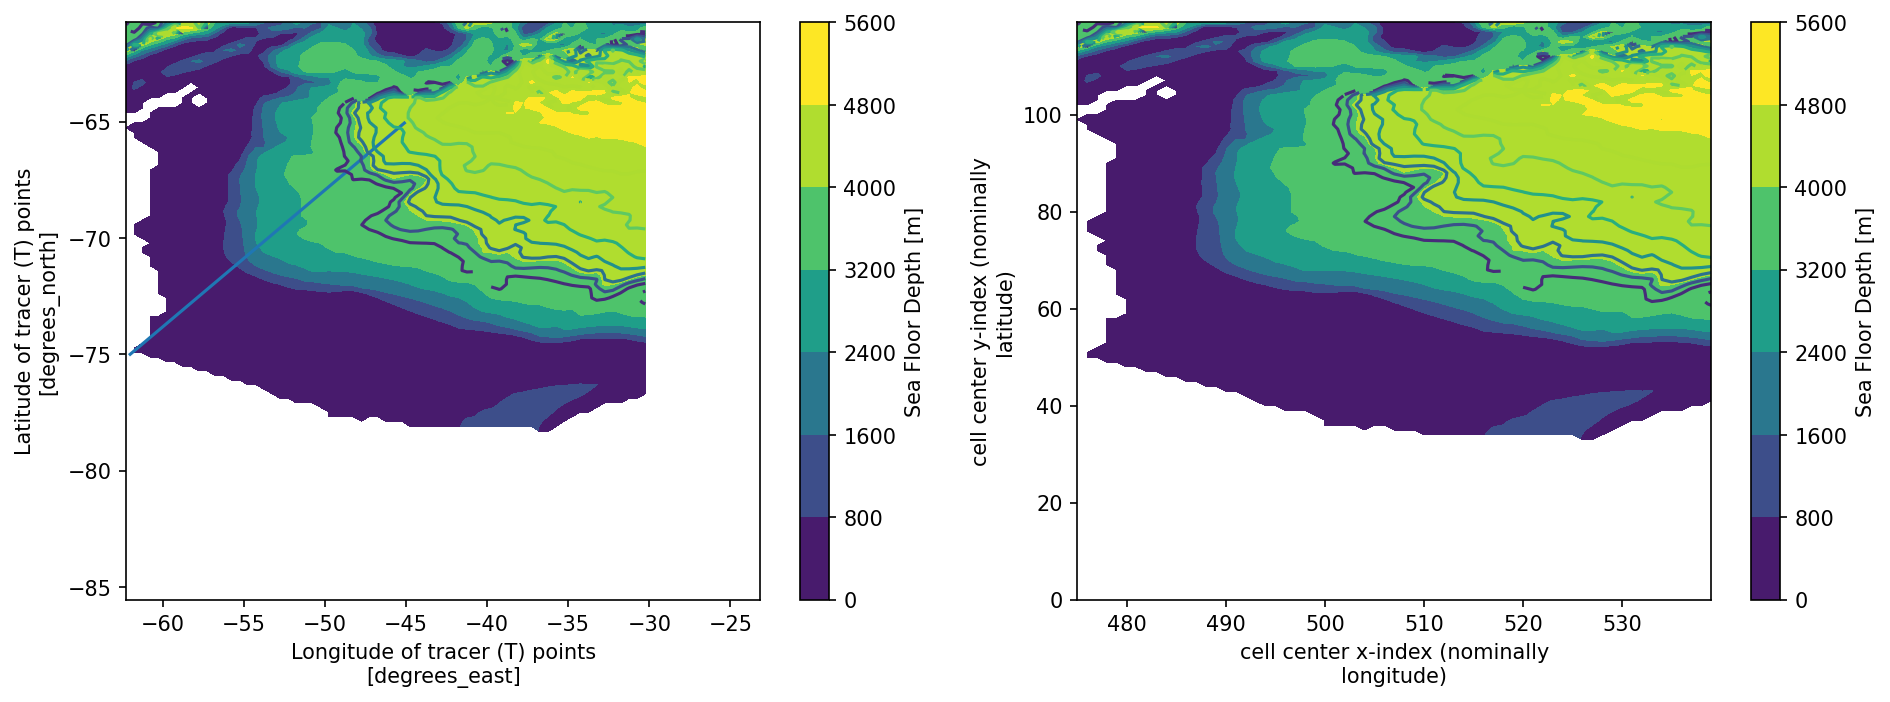

In [11]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds.isel(xh = slice(475, 540)).deptho.plot.contourf(ax = ax[0], x = "geolon", y = "geolat")
ax[0].plot(ds_locs["lon"], ds_locs["lat"])

ds.isel(xh = slice(475, 540)).deptho.plot.contourf(ax = ax[1])

ds.deptho.where((ds.isel(xh = slice(475, 540)).deptho < 4800) * (ds.isel(xh = slice(475, 540)).deptho > 3600) ).plot.contour(c = "red", ax = ax[0], x = "geolon", y = "geolat")
ds.deptho.where((ds.isel(xh = slice(475, 540)).deptho < 4800) * (ds.isel(xh = slice(475, 540)).deptho > 3600) ).plot.contour(c = "red", ax = ax[1])


In [12]:
regridder = setup_regridder(ds, ds_locs)
ds_remap = apply_regridder(regridder, ds).compute()
ds_masked = ds_remap.where(ds_remap > 0.0)

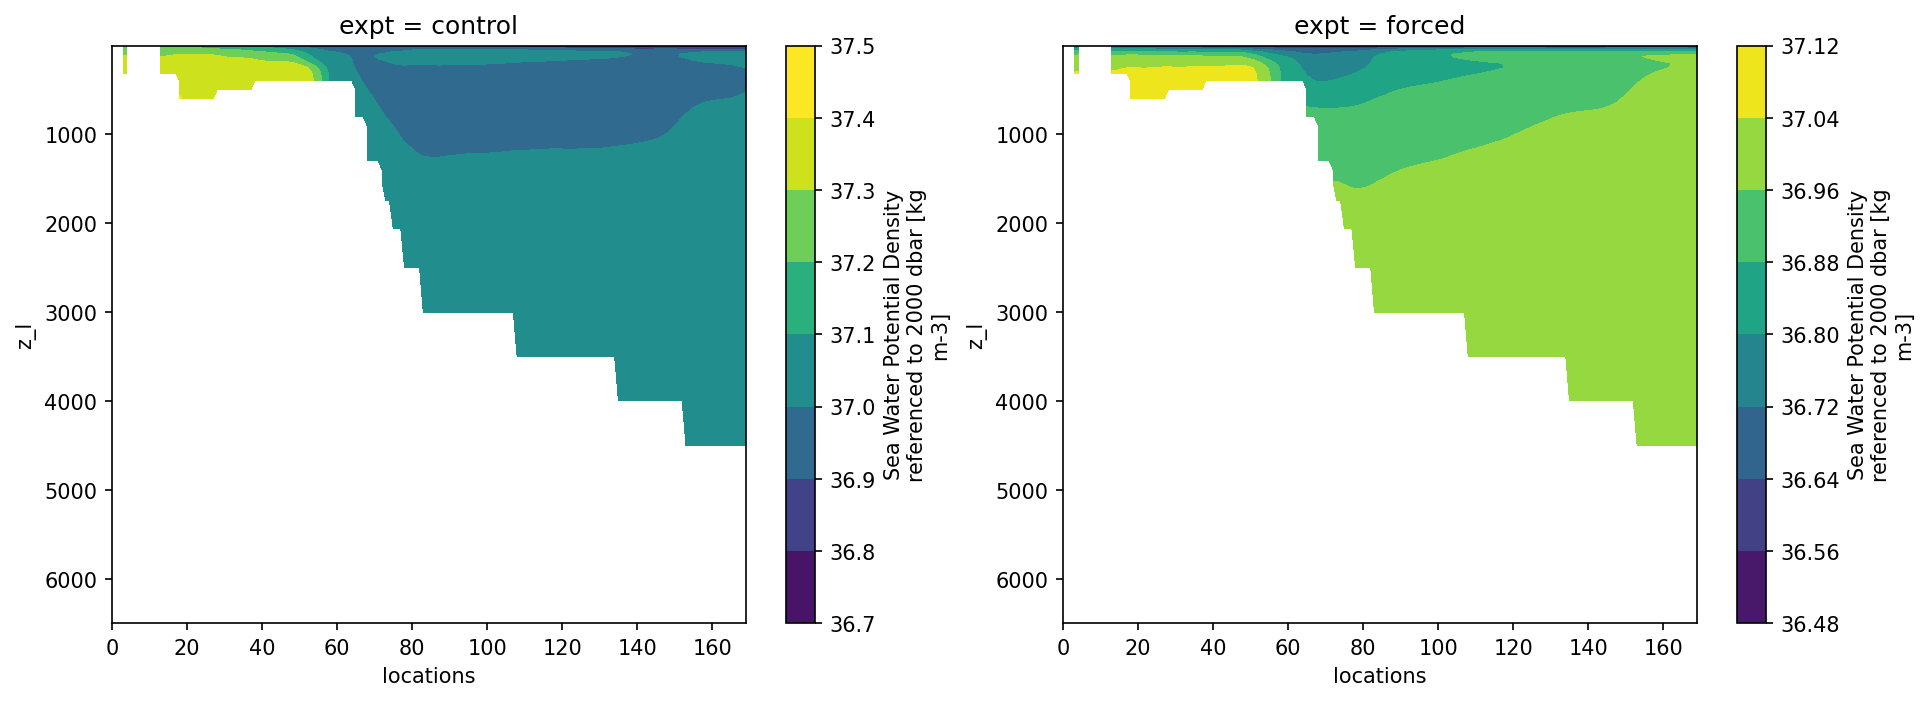

In [13]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_masked.sel(expt = "control", year = slice(2000, 2100)).sigma2_offline.mean("year").plot.contourf(ax = ax[0], yincrease = False)
ds_masked.sel(expt = "forced", year = slice(2000, 2100)).sigma2_offline.mean("year").plot.contourf(ax = ax[1],yincrease = False)

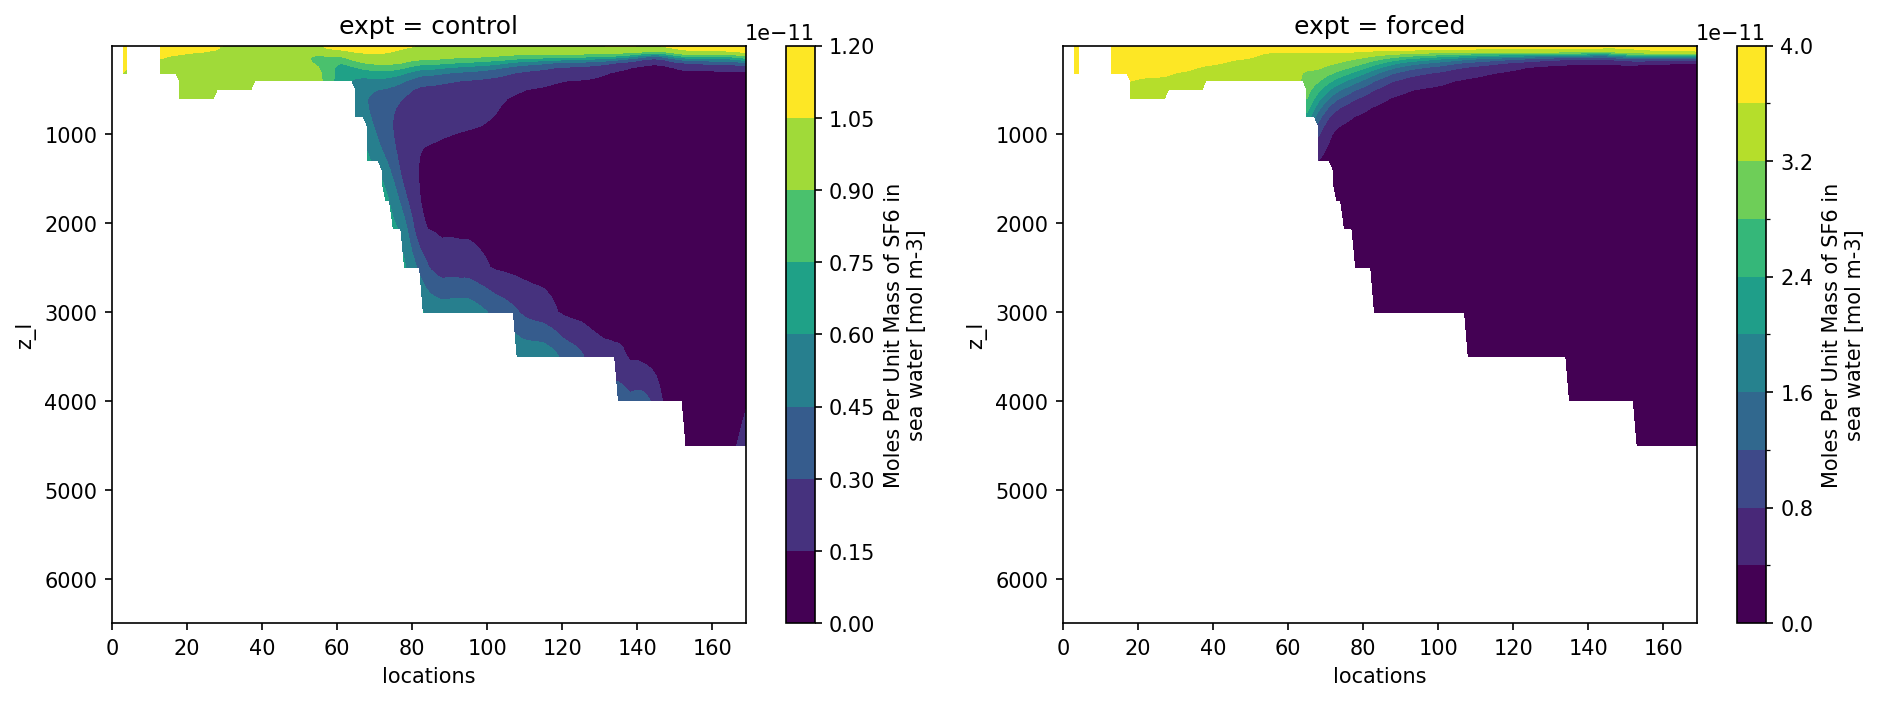

In [14]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
ds_masked.sel(expt = "control").sel(year = slice(2050, 2100)).mean("year").sf6.plot.contourf(ax = ax[0], yincrease = False, levels= 12)
(3 * ds_masked.sel(expt = "forced")).sel(year =slice(2050, 2100)).mean("year").sf6.plot.contourf(ax = ax[1],yincrease = False, levels= 12)

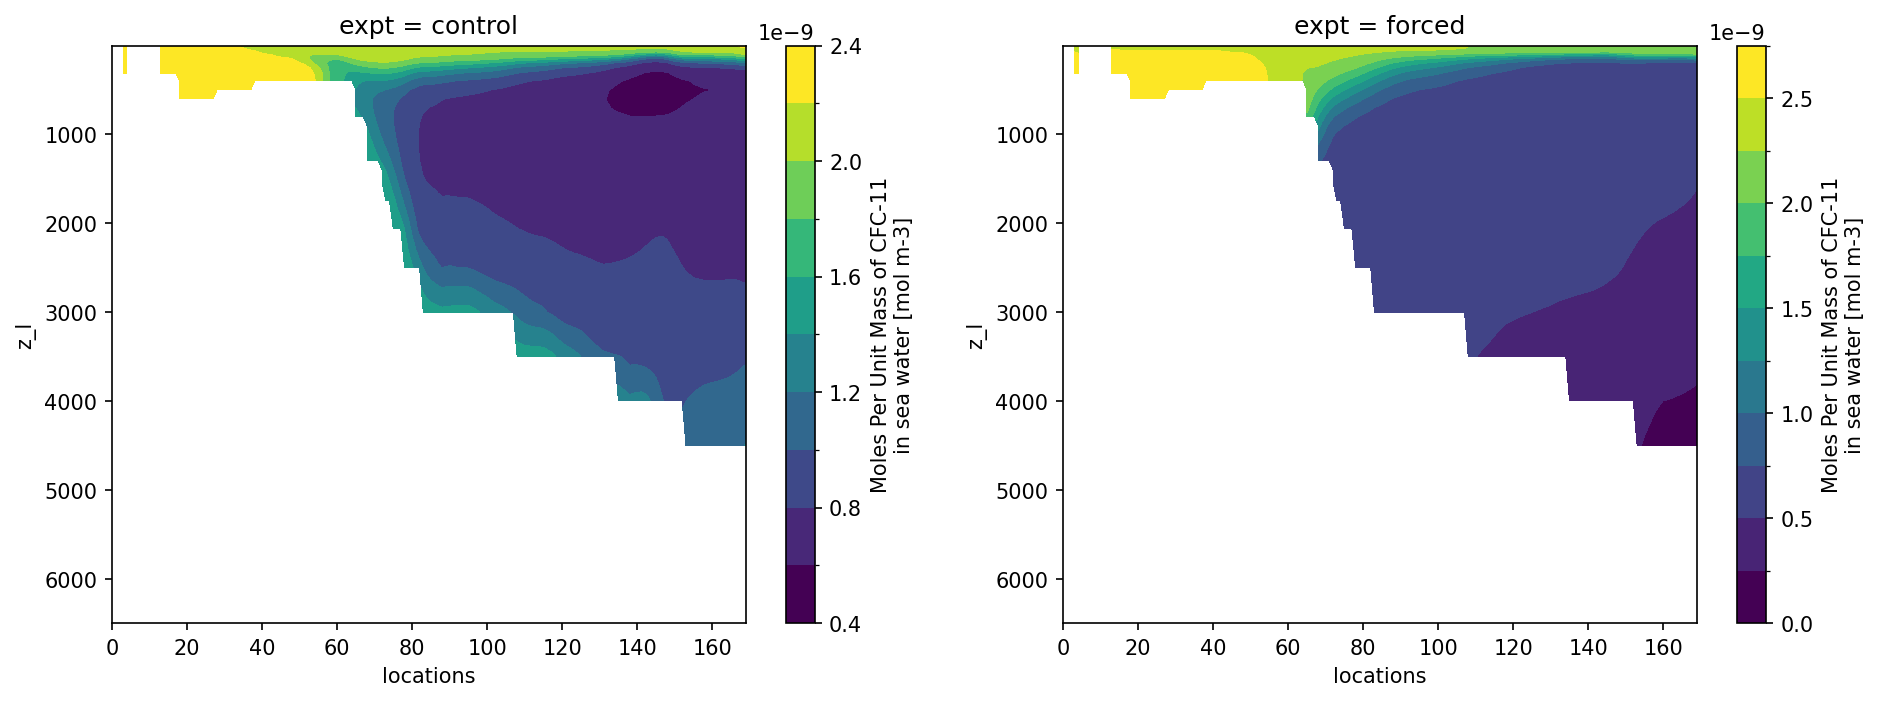

In [15]:
fig, ax = plt.subplots(1,2, figsize = (15, 5))
levels = np.linspace(5, 9, 20)
ds_masked.sel(expt = "control", year = slice(2050, 2100)).cfc11.mean("year").plot.contourf(ax = ax[0], yincrease = False, levels= 12)
ds_masked.sel(expt = "forced", year = slice(2050, 2100)).cfc11.mean("year").plot.contourf(ax = ax[1],yincrease = False, levels= 12)

In [16]:
def zonal_average(ds): 
    weights = ds.volcello; weights = weights.where(weights >0)
    vars_avg = (ds.drop_vars(["volcello"]) * weights).sum("xh") / weights.sum("xh")
    lats_avg = (ds.geolat).mean(["xh"])
    vars_avg.coords["yh"] = lats_avg
    vars_avg = vars_avg.rename({"yh":"geolat"})
    return vars_avg

def volume_average(ds): 
    weights = ds.volcello; weights = weights.where(weights >0)

    return (weights * ds.drop_vars(["volcello"])).sum(["xh", "yh"]) / weights.sum(["xh", "yh"])

In [17]:
ds_wedell = ds.isel(xh = slice(485, 540)).isel(yh = slice(0, 90)).isel(yh = slice(25, None))
isobath_mask = ((ds_wedell.deptho < 4800) * (ds_wedell.deptho > 3600)).compute()
isobath_mask = isobath_mask * 1.

In [18]:
ds_zon = zonal_average(ds_wedell).compute()

In [50]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.ticker import FixedLocator


def weddell_panel(var, mask, z=slice(0, 5000), avg_yrs=slice(2075, None), scale=1.0, 
                  log_scale_contours = False, units="", clabel_colors = "k",
                  levels=None, cmap=None, norm = None, surf_loc=(-77.5, 100), bot_loc=(-68.5, 4300),
                  section_title="", top_timeseries_title="", bot_timeseries_title="", plot_contours = False):
    fig = plt.figure(figsize=(13, 5), constrained_layout=True)
    gs = fig.add_gridspec(4, 3, width_ratios=(0.9, 1.2, 1.0))

    axA = fig.add_subplot(gs[1:3, 0], projection=ccrs.SouthPolarStereo())
    axB = fig.add_subplot(gs[0:2, 1])
    axC = fig.add_subplot(gs[2:, 1], sharex=axB)
    axD = fig.add_subplot(gs[0:2, 2])
    axE = fig.add_subplot(gs[2:, 2], sharex=axD)
    ax = [axA, axB, axD, axC, axE]

    axA.add_feature(cfeature.LAND, zorder=2)
    axA.add_feature(cfeature.COASTLINE, linewidth=0.6, zorder=3)
    axA.contourf(mask.geolon, mask.geolat, mask.values, levels=[0.5, 1.5], colors="red",
                 alpha=1.0, transform=ccrs.PlateCarree())
    # after you create axA (your cartopy axis)
    xticks = np.arange(-180, 181, 10)
    yticks = np.arange(-80, -49, 5)

    gl = axA.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=0.4, alpha=0.5)
    gl.xlocator = FixedLocator(xticks)
    gl.ylocator = FixedLocator(yticks)
    gl.top_labels = True
    gl.right_labels = True
    gl.bottom_labels = False
    gl.left_labels = False
    
    gl.x_inline = False
    gl.y_inline = False
    gl.xpadding = 6   # points; increase to push farther outside
    gl.ypadding = 6
    gl.rotate_labels = False
    var = var.sel(z_l=z) * scale
    v = var.sel(year=avg_yrs)
    y0, y1 = int(v.year.min()), int(v.year.max())
    v = v.mean("year")
    if log_scale_contours:
        v = np.log(v)
    if levels is None:
        a = np.asarray(v).ravel(); a = a[np.isfinite(a)]
        levels = np.linspace(a.min(), a.max(), 21) if a.size else 21

    axB.contourf(v.geolat, -v.z_l, v.sel(expt="control"), levels=levels, cmap=cmap, norm = norm, extend = "both")
    cf = axC.contourf(v.geolat, -v.z_l, v.sel(expt="forced"), levels=levels, cmap=cmap, norm = norm, extend = "both")

    if plot_contours: 
        CS = axB.contour(v.geolat, -v.z_l, v.sel(expt="control"), levels=levels, colors=clabel_colors, extend = "both")
        axB.clabel(CS, CS.levels, fontsize=9)
        CS = axC.contour(v.geolat, -v.z_l, v.sel(expt="forced"), levels=levels, colors=clabel_colors, extend = "both")
        axC.clabel(CS, CS.levels, fontsize=9)

    axB.set_title(section_title)

    axB.text(0.02, 0.03, f"control ({y0}-{y1})", transform=axB.transAxes, color="w", ha="left", va="bottom")
    axC.text(0.02, 0.03, f"forced ({y0}-{y1})",  transform=axC.transAxes, color="w", ha="left", va="bottom")

    lat_s, z_s = surf_loc
    lat_b, z_b = bot_loc
    for a in (axB, axC):
        a.plot(lat_s, -z_s, marker="*", ms=10, mfc="yellow", mec="k", mew=0.8, zorder=10)
        a.plot(lat_b, -z_b, marker="s", ms=6,  mfc="yellow", mec="k", mew=0.8, zorder=10)

    axB.set_ylabel("Depth [m]"); axC.set_ylabel("Depth")
    axB.set_xlabel(""); axC.set_xlabel("Latitude")
    axB.tick_params(labelbottom=False)
    axB.set_facecolor("grey"); axC.set_facecolor("grey")

    colors = {"control": "k", "forced": "r"}

    ts = var.interp(geolat=lat_s, z_l=z_s)
    tb = var.interp(geolat=lat_b, z_l=z_b)

    for expt, c in colors.items():
        axD.plot(ts.year, ts.sel(expt=expt), label=expt, c=c)
        axE.plot(tb.year, tb.sel(expt=expt), label=expt, c=c)
    axD.tick_params(labelbottom=False)

    axD.set_title(top_timeseries_title)
    axE.set_title(bot_timeseries_title)
    axD.set_ylabel(f"{units}")
    axE.set_ylabel(f"{units}")
    axD.legend(); axE.legend()
    fig.colorbar(cf, ax=ax, label=units, fraction=0.05, extend = "both")
    return fig, ax


In [53]:
import cmocean.cm as cmo
import cmocean

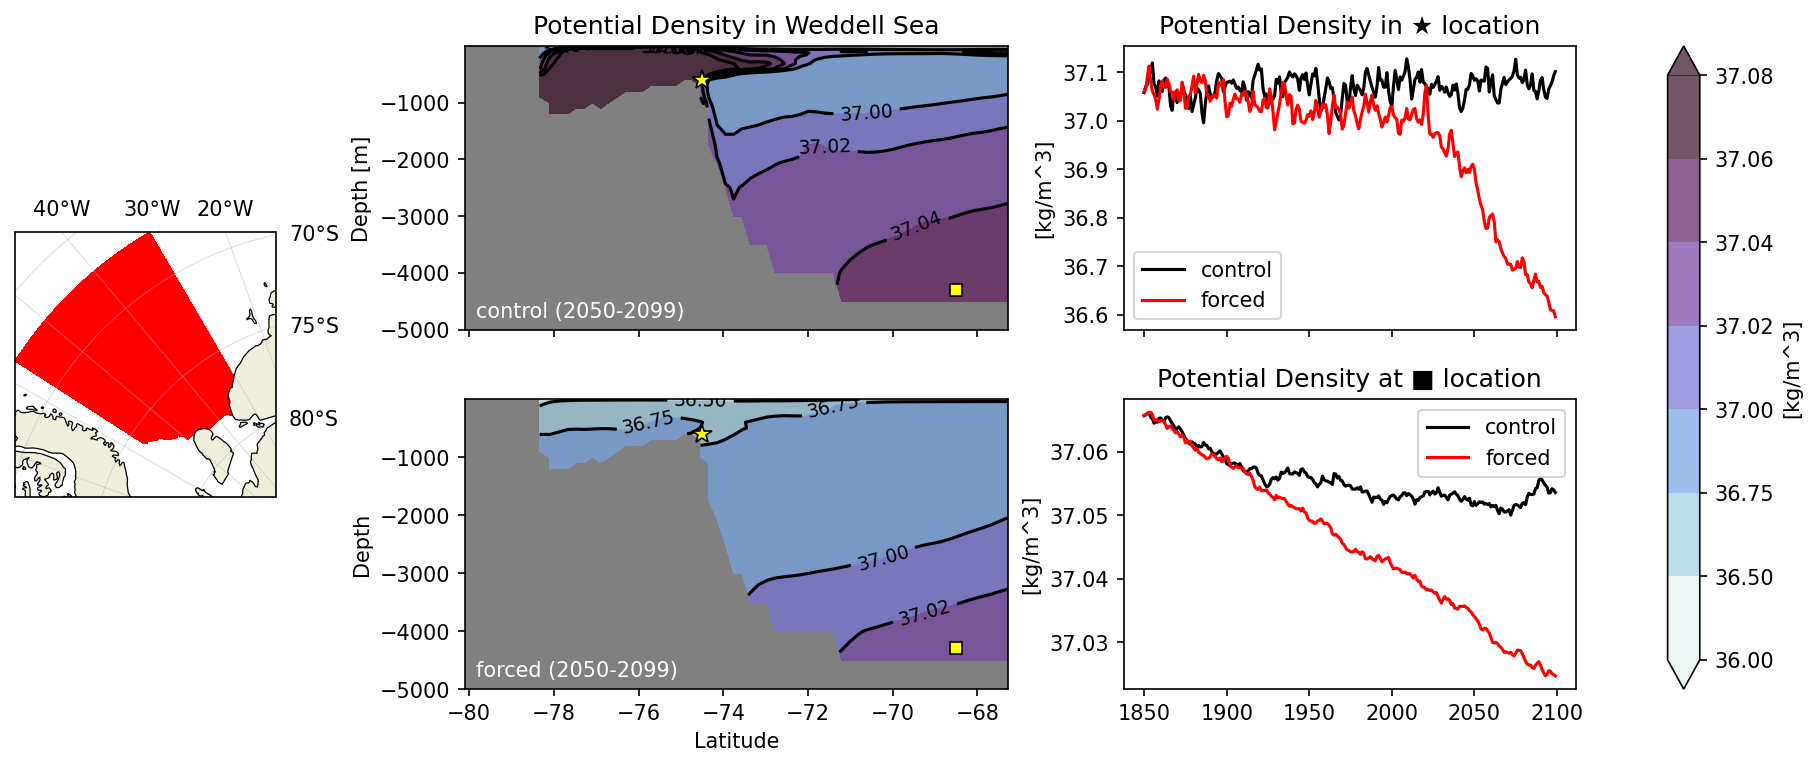

In [70]:
from matplotlib.colors import BoundaryNorm

mask = (ds_wedell.wet > 0).astype(np.int8)
levels = [36.0, 36.5, 36.75, 37.00, 37.02, 37.04, 37.06, 37.08]
cmap = plt.get_cmap(cmocean.tools.lighten(cmo.dense, 0.7), len(levels) - 1)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

var = ds_zon.sigma2_offline
fig, ax = weddell_panel(var, mask, z=slice(0, 5000), avg_yrs=slice(2050, None),
                        levels=levels, units="[kg/m^3]", cmap = cmap, norm = norm, 
                        plot_contours =True, clabel_colors = "k", 
                        surf_loc=(-74.5, 600), bot_loc=(-68.5, 4300), 
                       section_title =  "Potential Density in Weddell Sea", 
                       top_timeseries_title =  "Potential Density in ★ location", 
                       bot_timeseries_title =  "Potential Density at ■ location")

fig.savefig("poster_plots/density_weddell_average.png", dpi = 150, bbox_inches = "tight")

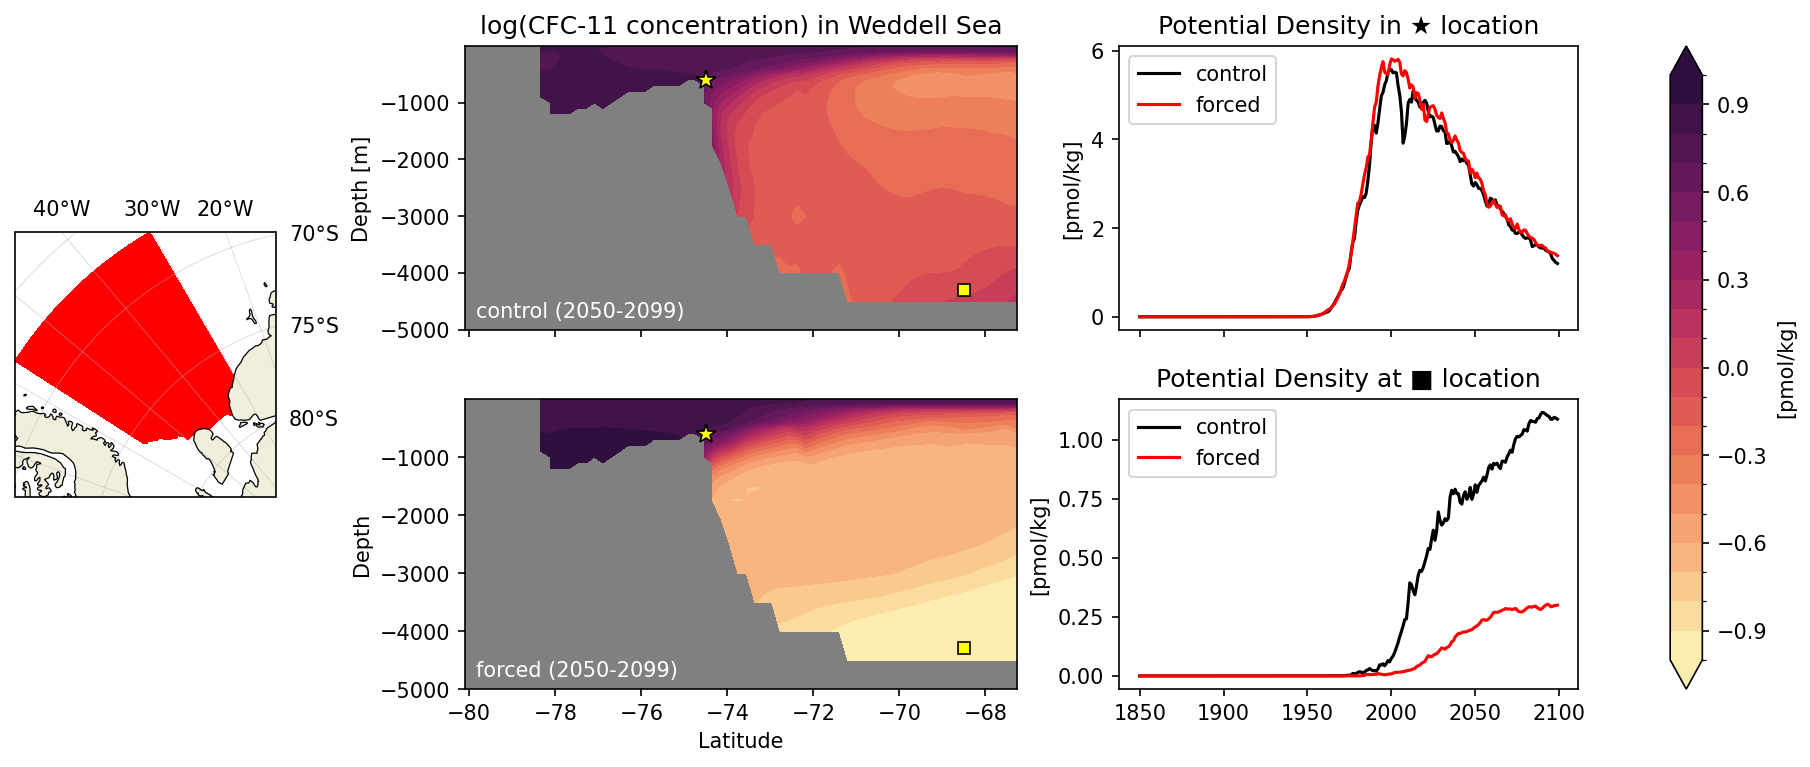

In [85]:
mask = (ds_wedell.wet > 0).astype(np.int8)
levels = np.arange(-1, 1 + 0.01, 0.1)
cmap = plt.get_cmap(cmo.matter, len(levels) - 1)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)

var = ds_zon.cfc11 * (1e12/1035)
fig, ax = weddell_panel(var, mask, z=slice(0, 5000), avg_yrs=slice(2050, None),
                        levels=levels, units="[pmol/kg]",
                        cmap = cmap, norm = norm, 
                        log_scale_contours = True, 
                        surf_loc=(-74.5, 600), bot_loc=(-68.5, 4300), 
                        plot_contours =False,
                       section_title =  "log(CFC-11 concentration) in Weddell Sea", 
                       top_timeseries_title =  "Potential Density in ★ location", 
                       bot_timeseries_title =  "Potential Density at ■ location")
fig.savefig("poster_plots/cfc11_weddell_average.png", dpi = 150, bbox_inches = "tight")

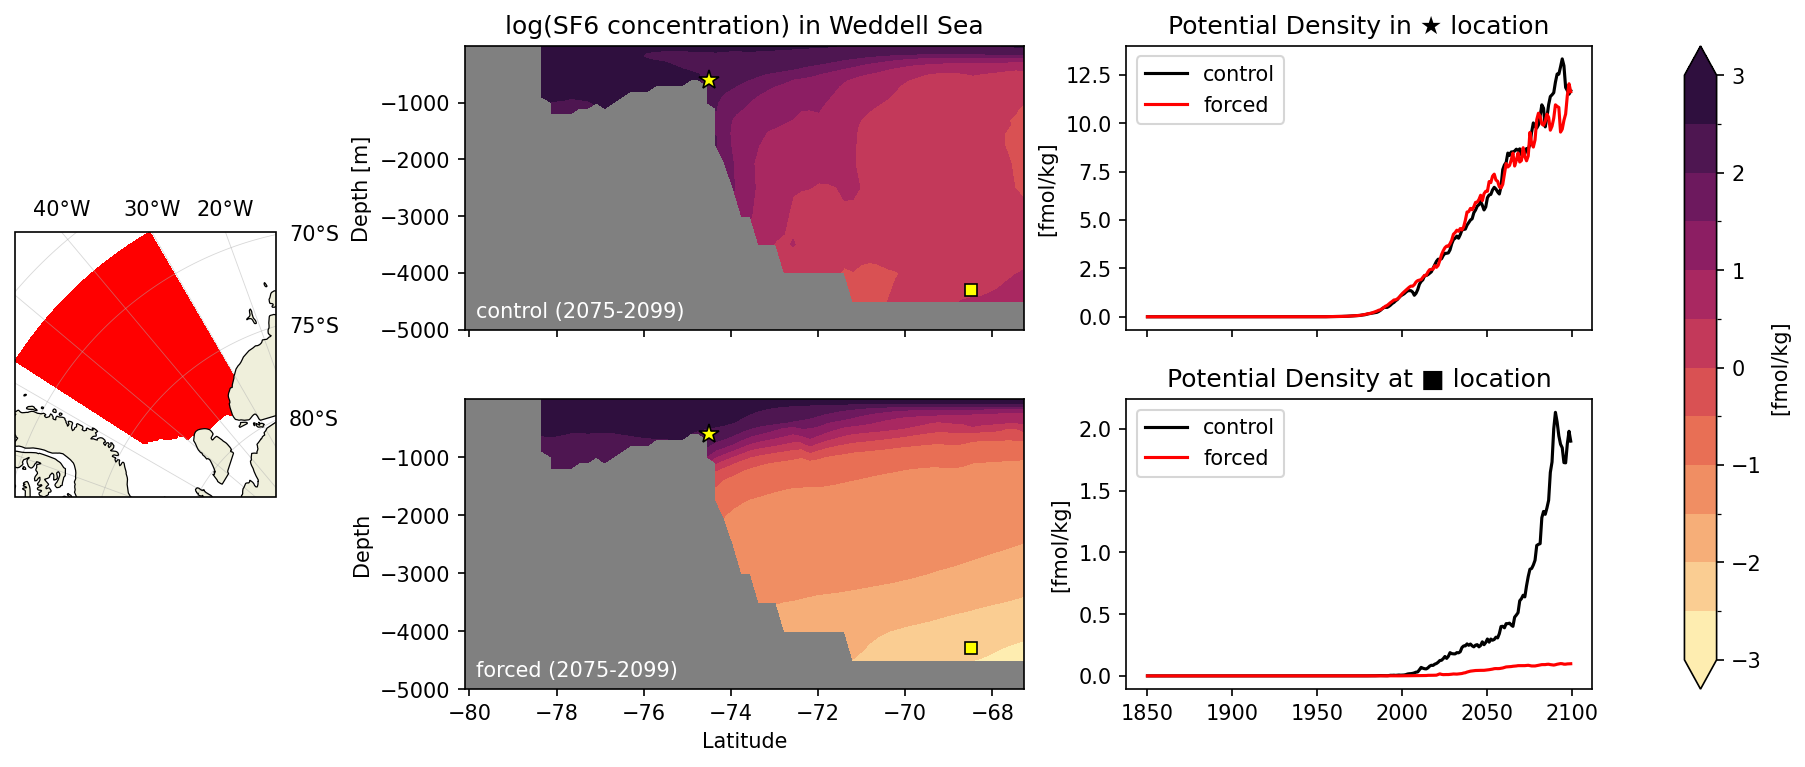

In [83]:
mask = (ds_wedell.wet > 0).astype(np.int8)
levels = np.arange(-3, 3 + 0.01, 0.5)
cmap = plt.get_cmap(cmo.matter, len(levels) - 1)
norm = BoundaryNorm(levels, ncolors=cmap.N, clip=True)
var = ds_zon.sf6 * 1e12/1035 *1e3

fig, ax = weddell_panel(var, mask, z=slice(0, 5000), avg_yrs=slice(2075, None),
                        levels=levels, units="[fmol/kg]",
                        cmap = cmap, norm = norm, 
                        log_scale_contours = True, 
                        surf_loc=(-74.5, 600), bot_loc=(-68.5, 4300), 
                        plot_contours =False,
                       section_title =  "log(SF6 concentration) in Weddell Sea", 
                       top_timeseries_title =  "Potential Density in ★ location", 
                       bot_timeseries_title =  "Potential Density at ■ location")
fig.savefig("poster_plots/sf6_weddell_average.png", dpi = 150, bbox_inches = "tight")

In [210]:
import numpy as np
import xarray as xr
from scipy.interpolate import PchipInterpolator

def pchip_d2(da: xr.DataArray, dim: str, x_new=None) -> xr.DataArray:
    x = da[dim].values

    if np.issubdtype(x.dtype, np.datetime64):
        x = (x.astype("datetime64[ns]").astype("int64") / 1e9).astype(float)
    else:
        x = x.astype(float)

    order = np.argsort(x)
    x_sorted = x[order]

    if x_new is None:
        x_new = x_sorted
        out_dim = dim
    else:
        x_new = np.asarray(x_new, dtype=float)
        out_dim = f"{dim}_new"

    def _d2_1d(y):
        y = np.asarray(y)[order]
        m = np.isfinite(x_sorted) & np.isfinite(y)

        xs = x_sorted[m]
        ys = y[m]
        if xs.size < 4:
            return np.full_like(x_new, np.nan, dtype=float)

        # Require strict monotonicity after NaN filtering
        if np.any(np.diff(xs) <= 0):
            return np.full_like(x_new, np.nan, dtype=float)

        p = PchipInterpolator(xs, ys, extrapolate=False)
        return p.derivative(2)(x_new)

    d2 = xr.apply_ufunc(
        _d2_1d,
        da,
        input_core_dims=[[dim]],
        output_core_dims=[[out_dim]],
        vectorize=True,
        dask="parallelized",
        output_dtypes=[float],
    )
    

    if x_new is None:
        return d2.assign_coords({dim: x_sorted})
    return d2.assign_coords({out_dim: x_new})

def d1_centered_3pt(da, dim):
    x = da[dim].astype(float)
    y = da

    y_im1 = y.shift({dim: 1})
    y_i   = y
    y_ip1 = y.shift({dim: -1})

    x_im1 = x.shift({dim: 1})
    x_i   = x
    x_ip1 = x.shift({dim: -1})

    h0 = x_i - x_im1
    h1 = x_ip1 - x_i

    d1 = (-h1 / (h0 * (h0 + h1))) * y_im1 \
       + ((h1 - h0) / (h0 * h1)) * y_i   \
       + ( h0 / (h1 * (h0 + h1))) * y_ip1

    d1 = d1.where(np.isfinite(h0) & np.isfinite(h1) & (h0 != 0) & (h1 != 0))
    return d1

In [ ]:
var = ds_zon.interp(geolat = -68.5).sel(expt = "forced")
var["sf6"] = 1e12/1035

In [301]:
from scipy import linalg

var = ds_zon.interp(geolat = -68.5).sel(expt = "forced")
var["sf6"] *= 1e12/1035
var["cfc11"] *= 1e12/1035

dvardt = d1_centered_3pt(var, dim = "year") / 3.154e+7
dvardz2 = d2_centered_3pt(var, dim = "z_l")

min_year = 2050
depthl = 4000
dvardz2 = dvardz2.sel(year = slice(min_year, None)).interp(z_l = depthl)
dvardt = dvardt.sel(year = slice(min_year, None)).interp(z_l = depthl)


cfc11_mat = np.zeros((len(dvardt.cfc11.values[:-1]), 3))
sf6_mat = np.zeros((len(dvardt.cfc11.values[:-1]), 3))

cfc11_mat[:, 0]  = dvardz2.cfc11.values[:-1]
cfc11_mat[:, 1]  = 1

sf6_mat[:, 0]  = dvardz2.sf6.values[:-1]
sf6_mat[:, 2]  = 1

A = np.concatenate([cfc11_mat, sf6_mat], axis = 0)
y = np.concatenate([dvardt.cfc11.values[:-1], dvardt.sf6.values[:-1]], axis = 0)

a = linalg.pinv(A) @ y

cfc11_approx = a[0] *  dvardz2.cfc11.values[:-1] + a[1]
sf6_approx = a[0] *  dvardz2.sf6.values[:-1] + a[2]

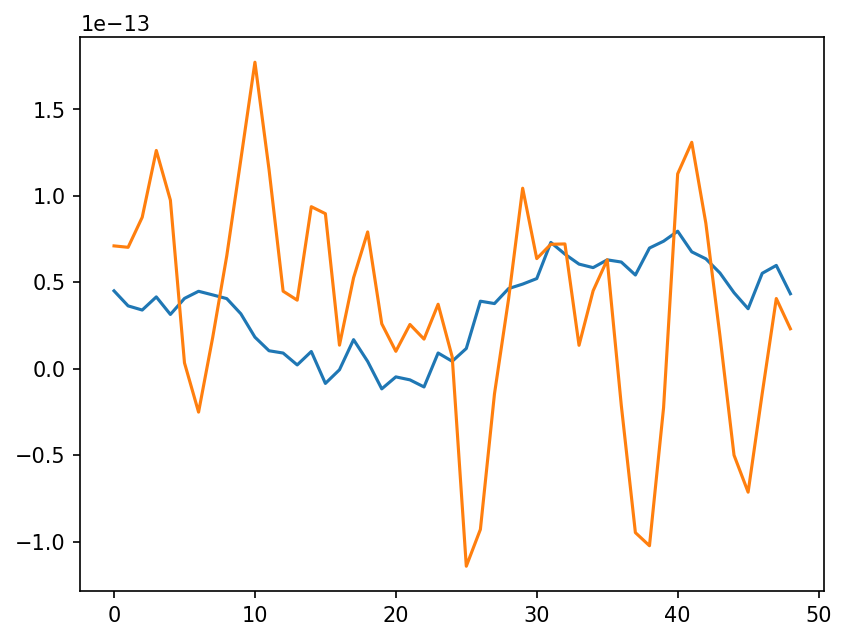

In [302]:
plt.plot(sf6_approx)
plt.plot(dvardt.sf6.values[:-1])

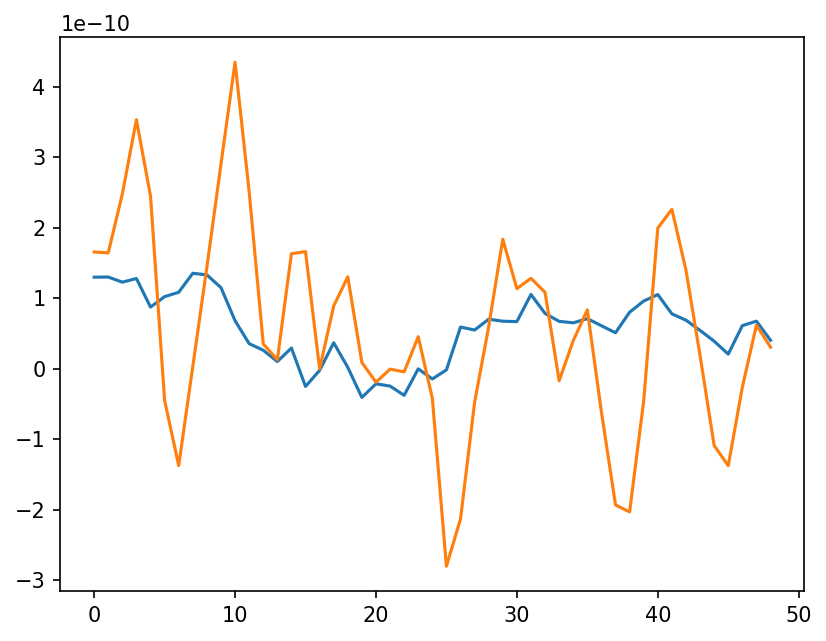

In [303]:
plt.plot(cfc11_approx)
plt.plot(dvardt.cfc11.values[:-1])

<xarray.DataArray ()> Size: 8B
array(0.00232018)
Coordinates:
    expt     <U7 28B 'control'
    geolat   float64 8B -68.5
    z_l      int64 8B 4000
Attributes:
    cell_measures:  volume: volcello area: areacello
    time_avg_info:  average_T1,average_T2,average_DT
    long_name:      Ocean grid-cell volume
    units:          m3
    cell_methods:   area:sum z_l:sum yh:sum xh:sum time: mean
    standard_name:  ocean_volume
    axis:           Z
    positive:       down
    edges:          z_i

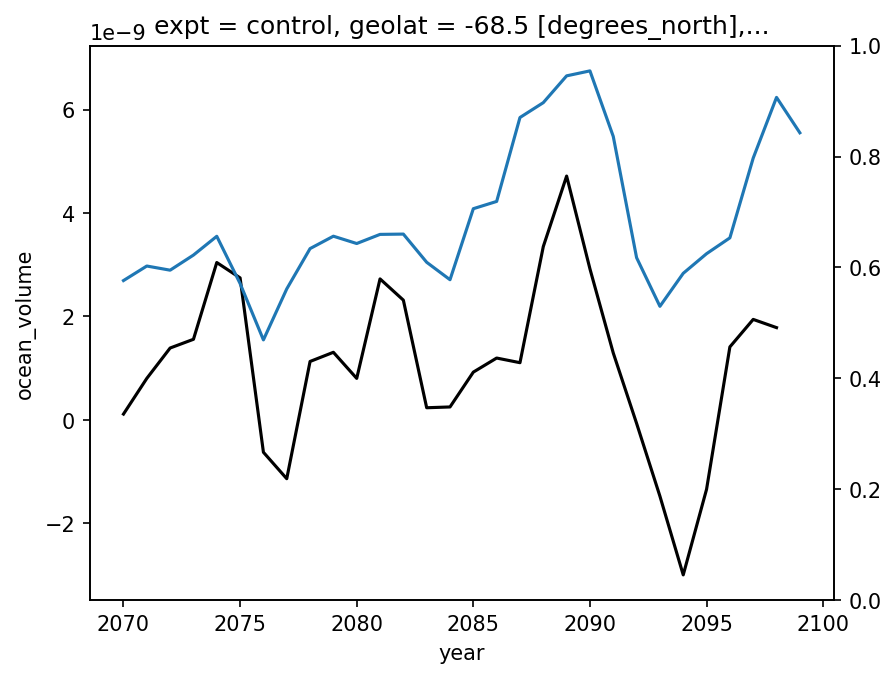

In [238]:
var = ds_zon.interp(geolat = -68.5).sf6 * 1e12/1035 *1e3
var_select = var.sel(expt = "control")


# fig, ax = plt.subplots()
# dvardt = d1_centered_3pt(var_select, dim = "year") / 3.154e+7
# dvardt.interp(z_l = 4000).sel(year = slice(2070, None)).plot(ax = ax, c = "k")

# ax_twin = ax.twinx()
# ((0.0020024) * d2_centered_3pt(var_select, dim = "z_l").interp(z_l = 4000).sel(year = slice(2070, None))).plot(ax = ax, )

# dvardt.interp(z_l = 4000).sel(year = slice(2070, None)).std() / d2_centered_3pt(var_select, dim = "z_l").interp(z_l = 4000).sel(year = slice(2070, None)).std()
